In [ ]:
#Demonstration: Supervised Learning - Regression

In [ ]:
##Scenario:

A real estate agency wants to estimate house prices in California based on various factors like location, number of rooms, and population density. 
They employ different machine learning models to predict prices and compare their predictions with actual market values to determine
the most accurate approach.

In [ ]:
##Step 1: Load and Explore the Dataset We use the California Housing Dataset to train and test the model to see the models's Performance

A Pandas DataFrame is created to store the dataset.

In [ ]:
pip install pandas

In [2]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
# Load dataset
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Price'] = data.target

# Display dataset sample
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
##Step 2: Preprocessing Data Features (X) are selected by removing the target variable (Price).

Data is standardized using StandardScaler to ensure all features are on the same scale.

SyntaxError: invalid syntax (2667449983.py, line 3)

In [5]:
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['Price'])
y = df['Price']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled)
print(y)

print("Data has been standardized.")

[[ 2.34476576  0.98214266  0.62855945 ... -0.04959654  1.05254828
  -1.32783522]
 [ 2.33223796 -0.60701891  0.32704136 ... -0.09251223  1.04318455
  -1.32284391]
 [ 1.7826994   1.85618152  1.15562047 ... -0.02584253  1.03850269
  -1.33282653]
 ...
 [-1.14259331 -0.92485123 -0.09031802 ... -0.0717345   1.77823747
  -0.8237132 ]
 [-1.05458292 -0.84539315 -0.04021111 ... -0.09122515  1.77823747
  -0.87362627]
 [-0.78012947 -1.00430931 -0.07044252 ... -0.04368215  1.75014627
  -0.83369581]]
0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: Price, Length: 20640, dtype: float64
Data has been standardized.


In [ ]:
##Step 3: Check for Multicollinearity Variance Inflation Factor (VIF) helps detect multicollinearity among features.

If a feature has a high VIF (>5 or >10), it indicates redundancy.

In [ ]:
pip install statsmodels

In [6]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np

vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]

print("Variance Inflation Factor (VIF) for each feature:")
print(vif_data)

Variance Inflation Factor (VIF) for each feature:
      Feature       VIF
0      MedInc  2.501295
1    HouseAge  1.241254
2    AveRooms  8.342786
3   AveBedrms  6.994995
4  Population  1.138125
5    AveOccup  1.008324
6    Latitude  9.297624
7   Longitude  8.962263


In [ ]:
##Step 4: Train-Test Split The dataset is split into 80% training data and 20% testing data.

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)
print("Data split into training and testing sets.")

(16512, 8)
(16512,)
(4128, 8)
(4128,)
Data split into training and testing sets.


In [ ]:

##Step 5: Train Multiple Regression Models Various regression models are trained, including Linear Regression,
Ridge, Lasso, ElasticNet, SVR, Decision Trees, and Gradient Boosting.

In [11]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Define models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "ElasticNet Regression": ElasticNet(alpha=0.1, l1_ratio=0.5),
    "Support Vector Regression": SVR(),
    "Decision Tree Regression": DecisionTreeRegressor(),
    "Random Forest Regression": RandomForestRegressor(n_estimators=100),
    "Gradient Boosting Regression": GradientBoostingRegressor()
}

print("Regression models initialized.")

Regression models initialized.


In [ ]:
##Step 6: Train and Evaluate Each Model Models are trained on X_train and y_train.

Predictions are made on X_test.

Models are evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), RMSE, and R-Square (R²).

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = []

for name, model in models.items():
    model.fit(X_train, y_train)  # Train model
    y_pred = model.predict(X_test)  # Make predictions

    # Calculate performance metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, mse, rmse, r2])

print("Model training and evaluation complete.")

Model training and evaluation complete.


In [ ]:
##Step 7: Compare Model Performance A DataFrame is created to display performance metrics.

RMSE is plotted to visually compare model perfo

In [ ]:
pip install seaborn

                          Model       MAE       MSE      RMSE  R-Square
0             Linear Regression  0.533200  0.555892  0.745581  0.575788
1              Ridge Regression  0.533193  0.555851  0.745554  0.575819
2              Lasso Regression  0.622148  0.679552  0.824349  0.481420
3         ElasticNet Regression  0.596967  0.635761  0.797346  0.514838
4     Support Vector Regression  0.397763  0.355198  0.595985  0.728941
5      Decision Tree Regression  0.455319  0.498121  0.705777  0.619874
6      Random Forest Regression  0.325419  0.251408  0.501406  0.808145
7  Gradient Boosting Regression  0.371650  0.293999  0.542217  0.775643


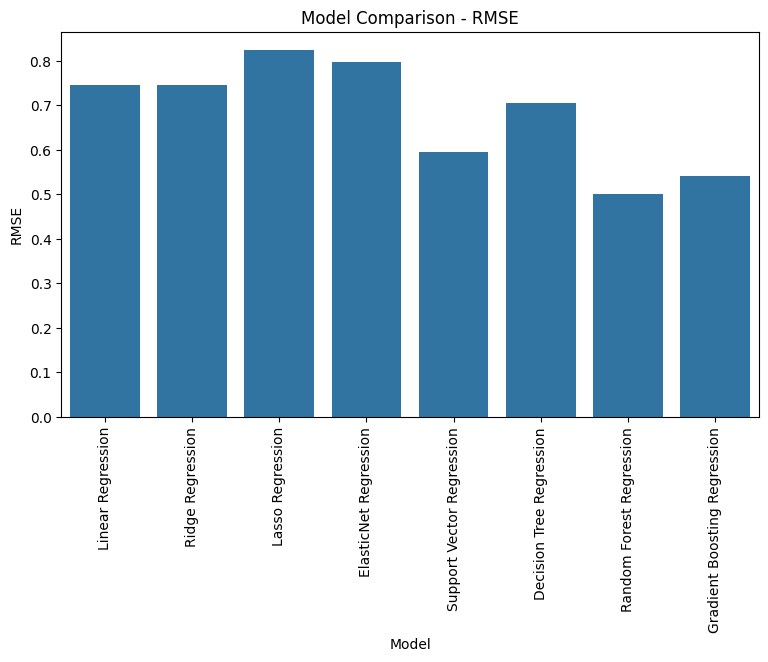

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

df_results = pd.DataFrame(results, columns=["Model", "MAE", "MSE", "RMSE", "R-Square"])
print(df_results)

# Plot comparison
plt.figure(figsize=(9, 5))
sns.barplot(x='Model', y='RMSE', data=df_results)
plt.xticks(rotation=90)
plt.title("Model Comparison - RMSE")
plt.show()

In [ ]:
##Step 8: Train a Final Model (Best Performing) Based on the results, we select Random Forest Regression as the best model.

We train it again and make final predictions

In [16]:
best_model = RandomForestRegressor(n_estimators=100)
best_model.fit(X_train, y_train)
final_predictions = best_model.predict(X_test)

# Final model evaluation
final_mae = mean_absolute_error(y_test, final_predictions)
final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)
final_r2 = r2_score(y_test, final_predictions)

print("Final Model Performance (Random Forest Regression):")
print(f"MAE: {final_mae}")
print(f"MSE: {final_mse}")
print(f"RMSE: {final_rmse}")
print(f"R-Square: {final_r2}")

Final Model Performance (Random Forest Regression):
MAE: 0.3285945662063955
MSE: 0.2540903892915876
RMSE: 0.5040737934981223
R-Square: 0.8060984062909275


In [ ]:
The dataset was preprocessed, scaled, and split into training/testing sets.

Various regression models were trained and evaluated.

The best-performing model (Random Forest Regression) was selected and retrained.

The final model was evaluated using MAE, MSE, RMSE, and R².

In [ ]:
##Step 9: Training Model for Predicting Price

In [17]:
import warnings
# Suppress warnings
warnings.simplefilter(action='ignore', category=UserWarning)

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100),
    "Gradient Boosting Regressor": GradientBoostingRegressor(n_estimators=100),
    "Support Vector Regressor": SVR(),
}

# Train all models
for name, model in models.items():
    model.fit(X_train, y_train)

In [ ]:
##Step 10: Predicting House Prices

In [18]:
# Predict on test set
predictions = {}
print("Predicted vs Actual Prices:")
for name, model in models.items():
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    # Display first 5 predictions vs actual prices
    print(f"{name} Predictions:")
    comparison_df = pd.DataFrame({"Actual Price": y_test[:5].values, "Predicted Price": y_pred[:5]})
    print(comparison_df)
    print("-")

Predicted vs Actual Prices:
Linear Regression Predictions:
   Actual Price  Predicted Price
0       0.47700         0.719123
1       0.45800         1.764017
2       5.00001         2.709659
3       2.18600         2.838926
4       2.78000         2.604657
-
Decision Tree Regressor Predictions:
   Actual Price  Predicted Price
0       0.47700          0.41400
1       0.45800          1.20300
2       5.00001          5.00001
3       2.18600          2.86700
4       2.78000          2.25700
-
Random Forest Regressor Predictions:
   Actual Price  Predicted Price
0       0.47700         0.489880
1       0.45800         0.716410
2       5.00001         4.914186
3       2.18600         2.508410
4       2.78000         2.331760
-
Gradient Boosting Regressor Predictions:
   Actual Price  Predicted Price
0       0.47700         0.505188
1       0.45800         1.093346
2       5.00001         4.245710
3       2.18600         2.545174
4       2.78000         2.279103
-
Support Vector Regressor P